# CCAnalyzer — Paper Figures from the Local Exp4/Exp5/Exp6 Campaign

Reproduces the **queue-occupancy figures** of *CCAnalyzer* (Ware et al., SIGCOMM '24)
from the traces collected by `run_cc_campaign.sh` into `cc_results/`.

| Notebook figure | Paper figure | Experiment | What it shows |
|---|---|---|---|
| Fig. 5 | **Figure 5** | Exp4 | Cubic queue occupancy vs queue size (5 Mbps / 275 ms) |
| Fig. 6 | **Figure 6** | Exp5 | BBR queue occupancy vs queue size (5 Mbps / 275 ms) |
| Fig. 1 | **Figure 1** | Exp1 | Four CCAs are visually distinct (NewReno / BBR / Cubic / BIC) |
| Fig. 23 | **Figure 23** | Exp6 | Example queue-occupancy traces for all 15 CCAs at one setting |
| Efficiency | **Figure 17**-flavor | Exp6 | Orchestration wall-clock + delivered volume/goodput (our-data only) |

**Data model.** Each run wrote a `*__queue_trace__*.jsonl` sampled every ~5 ms on two
veths. The **bottleneck queue is `veth2`** (its backlog fills to the configured
`buffer_packets`, and its `bytes_sent` ≈ link-rate × duration); `veth4` is the
reverse path. We plot `backlog_pkts` on `veth2` vs. time.

**Not reproducible from this pass:** the *classification* figures (Fig. 7–12) need the
1NN-DTW classifier with a separate train (3×) / test (5×) split. This campaign collected
**one trial per (setting, CCA)** — no train/test split, no repetitions — so accuracy
matrices can't be computed here. See the closing note.


In [1]:
import json, glob, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# cc_results lives next to this notebook (repo root). Adjust if you move the notebook.
RESULTS = Path("cc_results")
assert RESULTS.is_dir(), f"cannot find {RESULTS.resolve()} — run this notebook from the repo root"
FIGDIR = RESULTS  # save rendered PNGs alongside the data
BOTTLENECK_IFACE = "veth2"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "axes.titlesize": 11,
    "font.size": 10, "lines.linewidth": 0.7,
})

# kernel CC name -> paper name
PAPER_NAME = {
    "reno": "NewReno", "cubic": "Cubic", "bbr": "BBR", "bic": "BIC", "cdg": "CDG",
    "highspeed": "Highspeed", "htcp": "HTCP", "hybla": "Hybla", "illinois": "Illinois",
    "nv": "New Vegas", "scalable": "Scalable", "vegas": "Vegas", "veno": "Veno",
    "westwood": "Westwood", "yeah": "Yeah",
}
ALL_CCS = list(PAPER_NAME)
print("results dir:", RESULTS.resolve())
print("queue_trace files:", len(list(RESULTS.glob('*__queue_trace__*.jsonl'))))


results dir: /home/jaber/agentic-thin-waist/cc_results
queue_trace files: 183


In [2]:
def tag_for(cc, bw, rtt, q):
    return f"{cc}_{bw}bw-{rtt}rtt-{q}q"

def qtrace_path(tag):
    hits = sorted(RESULTS.glob(f"{tag}__queue_trace__*.jsonl"))
    return hits[0] if hits else None

def load_qtrace(tag, iface=BOTTLENECK_IFACE):
    # Return (t_rel_seconds, backlog_pkts, bytes_sent_cumulative) for one run.
    # backlog may contain NaN where the sampler returned null.
    p = qtrace_path(tag)
    if p is None:
        raise FileNotFoundError(f"no queue_trace for tag={tag}")
    t, bl, bs = [], [], []
    with open(p) as fh:
        for line in fh:
            d = json.loads(line)
            if d.get("iface") != iface:
                continue
            t.append(d["t"])
            b = d.get("backlog_pkts")
            bl.append(np.nan if b is None else float(b))
            bs.append(d.get("bytes_sent"))
    t = np.asarray(t, float)
    t = t - t[0]                      # seconds since run start
    return t, np.asarray(bl, float), np.asarray(bs, float)

def plot_trace(ax, tag, qcap=None, color="C0", tmax=60):
    t, bl, _ = load_qtrace(tag)
    m = ~np.isnan(bl) & (t <= tmax)
    ax.plot(t[m], bl[m], color=color)
    if qcap is not None:
        ax.axhline(qcap, ls="--", color="crimson", lw=0.9)
        ax.set_ylim(0, qcap * 1.08)
    ax.set_xlim(0, tmax)
    return t, bl

print("helpers ready")


helpers ready


## Figure 5 — Effect of queue size on **Cubic** (5 Mbps, 275 ms)

Cubic is loss-based: it inflates the queue until a drop, so it **fills whatever queue
you give it** (backlog rides at the red cap line). Larger queues → larger standing
queue → bufferbloat. This is the paper's motivation for sizing the queue to ≈1 BDP.


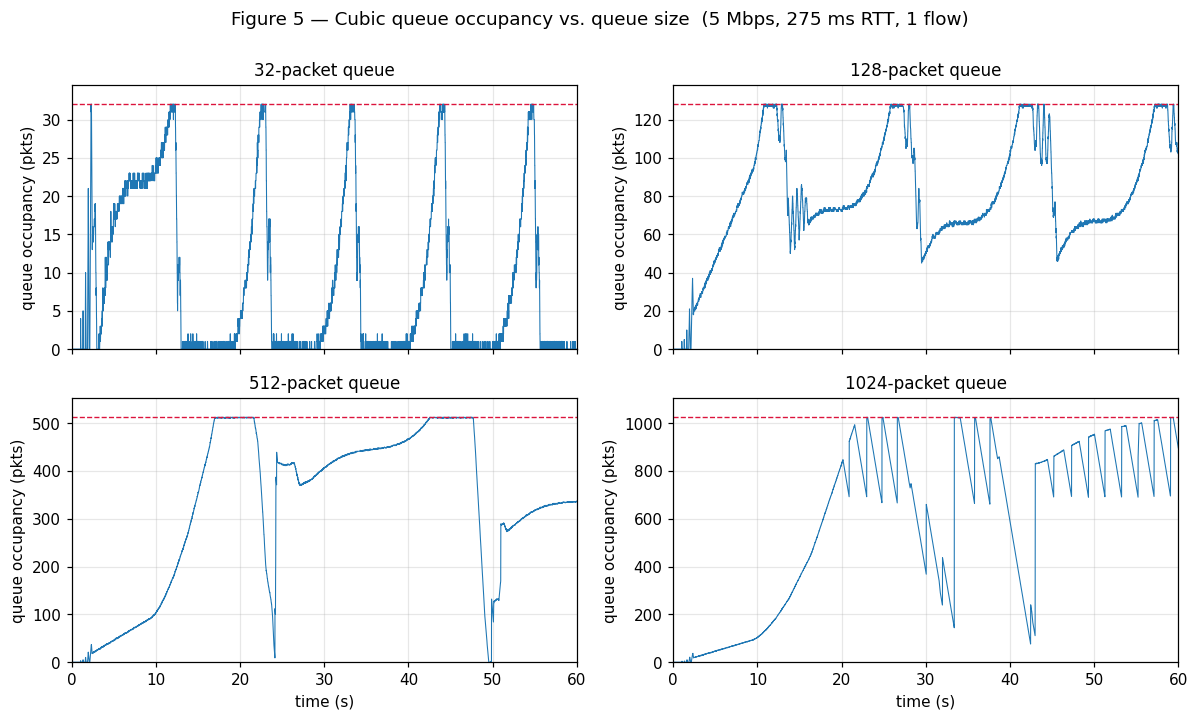

In [3]:
cc = "cubic"; QS = [32, 128, 512, 1024]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for ax, q in zip(axes.flat, QS):
    plot_trace(ax, tag_for(cc, 5, 275, q), qcap=q, color="C0")
    ax.set_title(f"{q}-packet queue")
    ax.set_ylabel("queue occupancy (pkts)")
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
fig.suptitle("Figure 5 — Cubic queue occupancy vs. queue size  (5 Mbps, 275 ms RTT, 1 flow)",
             fontsize=12, y=1.00)
fig.tight_layout()
fig.savefig(FIGDIR / "fig_paper05_cubic_queue_sweep.png")
plt.show()


## Figure 6 — Effect of queue size on **BBR** (5 Mbps, 275 ms)

BBR is model-based (rate/RTT estimation), so unlike Cubic it does **not** fill a large
queue — at 512/1024 packets the backlog stays far below the cap. Contrast the y-values
against Figure 5's Cubic panels at the same queue sizes.


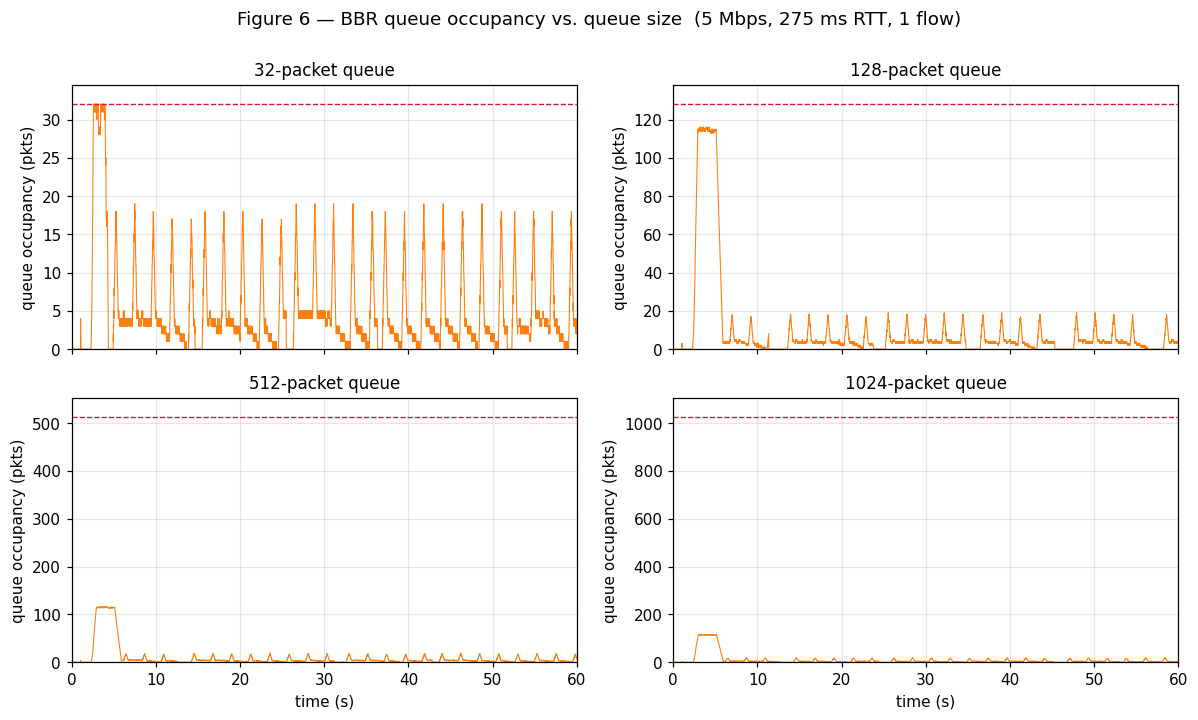

In [4]:
cc = "bbr"
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for ax, q in zip(axes.flat, QS):
    plot_trace(ax, tag_for(cc, 5, 275, q), qcap=q, color="C1")
    ax.set_title(f"{q}-packet queue")
    ax.set_ylabel("queue occupancy (pkts)")
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
fig.suptitle("Figure 6 — BBR queue occupancy vs. queue size  (5 Mbps, 275 ms RTT, 1 flow)",
             fontsize=12, y=1.00)
fig.tight_layout()
fig.savefig(FIGDIR / "fig_paper06_bbr_queue_sweep.png")
plt.show()


## Figure 1 — Four CCAs are visually distinct

The motivating claim: different CCAs leave visibly different queue-occupancy signatures,
which is what makes 1NN-DTW classification work. Shown at **10 Mbps / 130 ms / 128-pkt**
(one of the paper's four "most accurate" settings). The paper does not pin a setting for
Fig. 1, so we use this one; try any setting by editing `BW, RTT, Q` below.


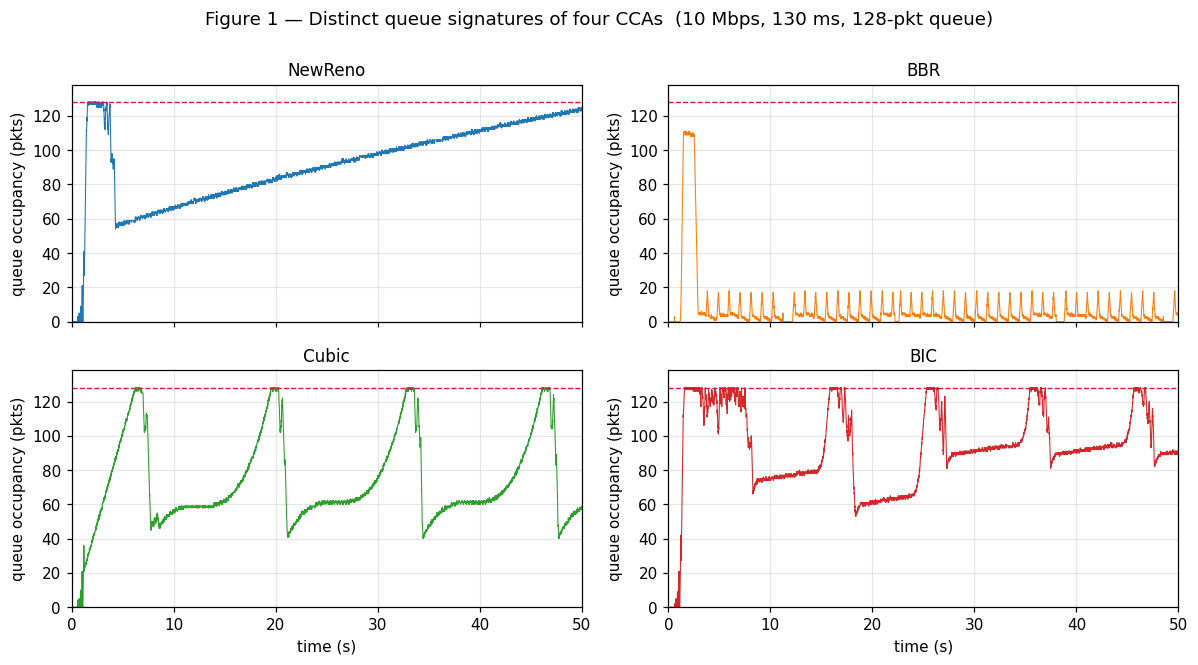

In [5]:
BW, RTT, Q = 10, 130, 128
FOUR = ["reno", "bbr", "cubic", "bic"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for ax, cc, col in zip(axes.flat, FOUR, ["C0", "C1", "C2", "C3"]):
    plot_trace(ax, tag_for(cc, BW, RTT, Q), qcap=Q, color=col, tmax=50)
    ax.set_title(PAPER_NAME[cc])
    ax.set_ylabel("queue occupancy (pkts)")
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
fig.suptitle(f"Figure 1 — Distinct queue signatures of four CCAs  ({BW} Mbps, {RTT} ms, {Q}-pkt queue)",
             fontsize=12, y=1.00)
fig.tight_layout()
fig.savefig(FIGDIR / "fig_paper01_four_ccas.png")
plt.show()


## Figure 23 — Example traces for all 15 CCAs (one setting)

The appendix "training-sample gallery": one queue-occupancy trace per CCA at a single
setting. We use **5 Mbps / 85 ms / 64-pkt** (paper's `5bw-85rtt-64q`, where Fig. 23 is
drawn). This is the full 15-CCA fingerprint set collected in this campaign.


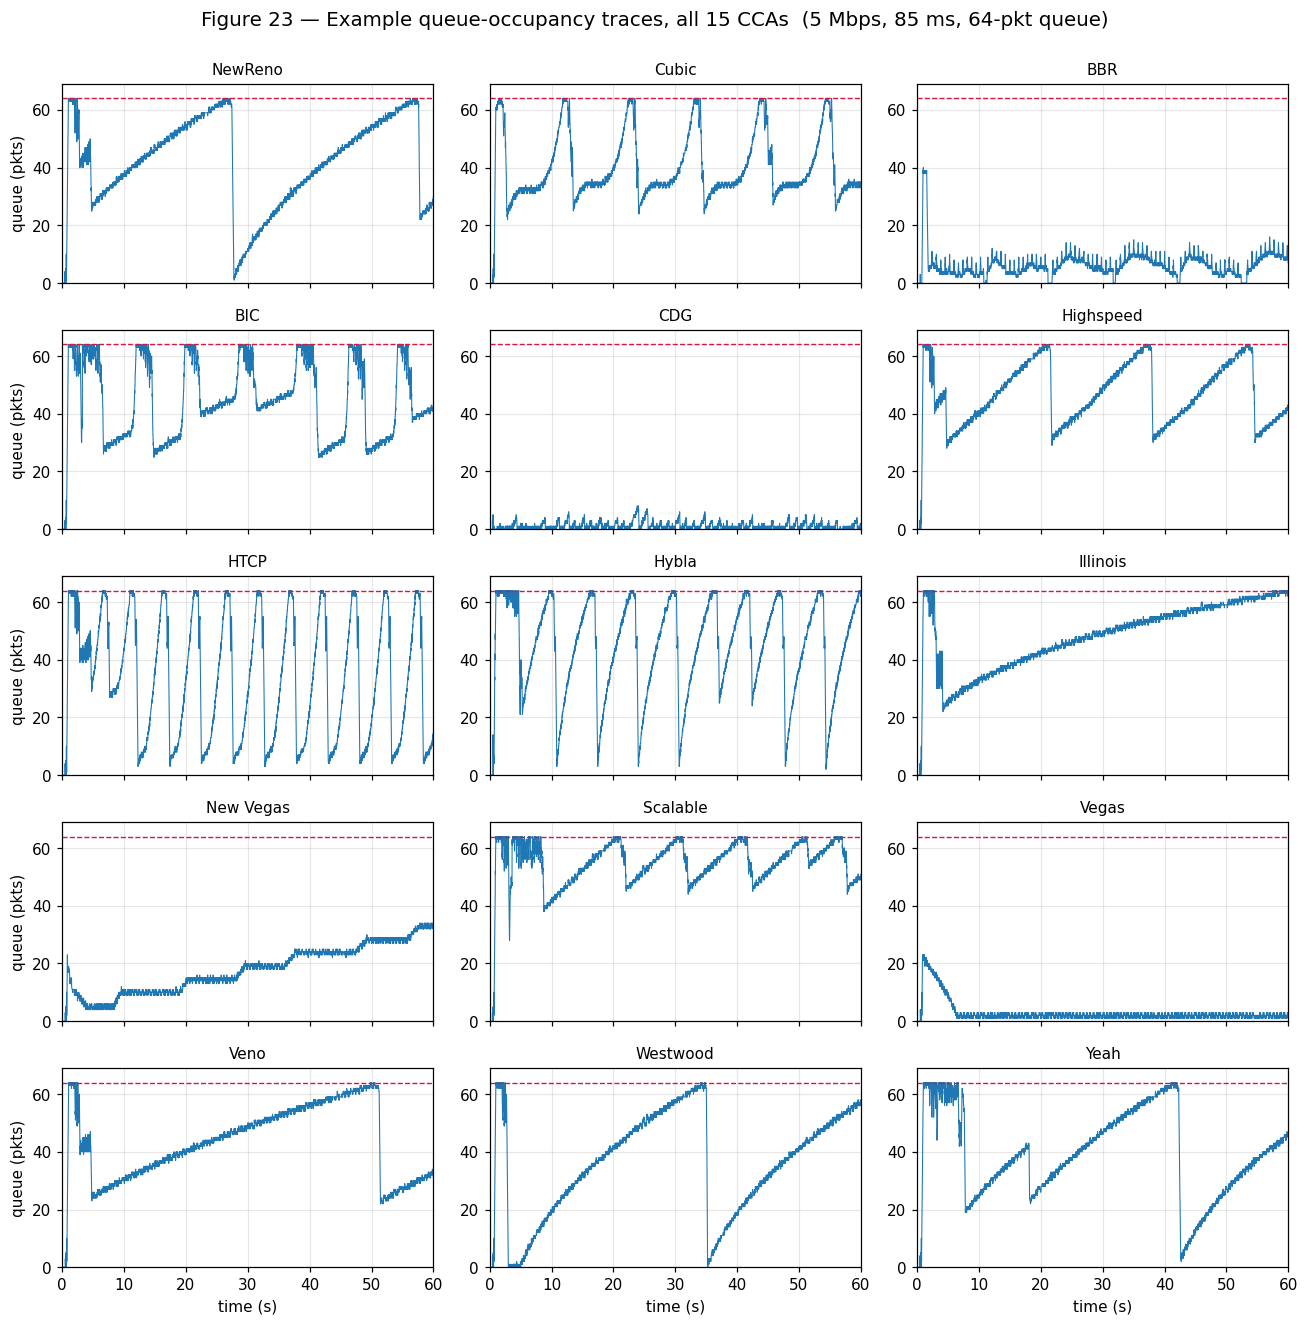

In [6]:
BW, RTT, Q = 5, 85, 64
fig, axes = plt.subplots(5, 3, figsize=(12, 12), sharex=True)
for ax, cc in zip(axes.flat, ALL_CCS):
    tag = tag_for(cc, BW, RTT, Q)
    try:
        plot_trace(ax, tag, qcap=Q, color="C0")
    except FileNotFoundError:
        ax.text(0.5, 0.5, f"{cc}\n(missing)", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(PAPER_NAME[cc], fontsize=10)
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("queue (pkts)")
fig.suptitle(f"Figure 23 — Example queue-occupancy traces, all 15 CCAs  ({BW} Mbps, {RTT} ms, {Q}-pkt queue)",
             fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(FIGDIR / "fig_paper23_all15_ccas.png")
plt.show()


## Efficiency & timing (Figure 17-flavor, our-data only)

The paper's Fig. 17 compares CCAnalyzer's **bytes transferred** and **wall-clock time**
against baseline tools. We only have the CCAnalyzer side, so this is a summary of *our*
collection cost, using `timing.csv` (orchestration wall-clock) and the delivered volume
computed from each run's final `veth2` `bytes_sent`.


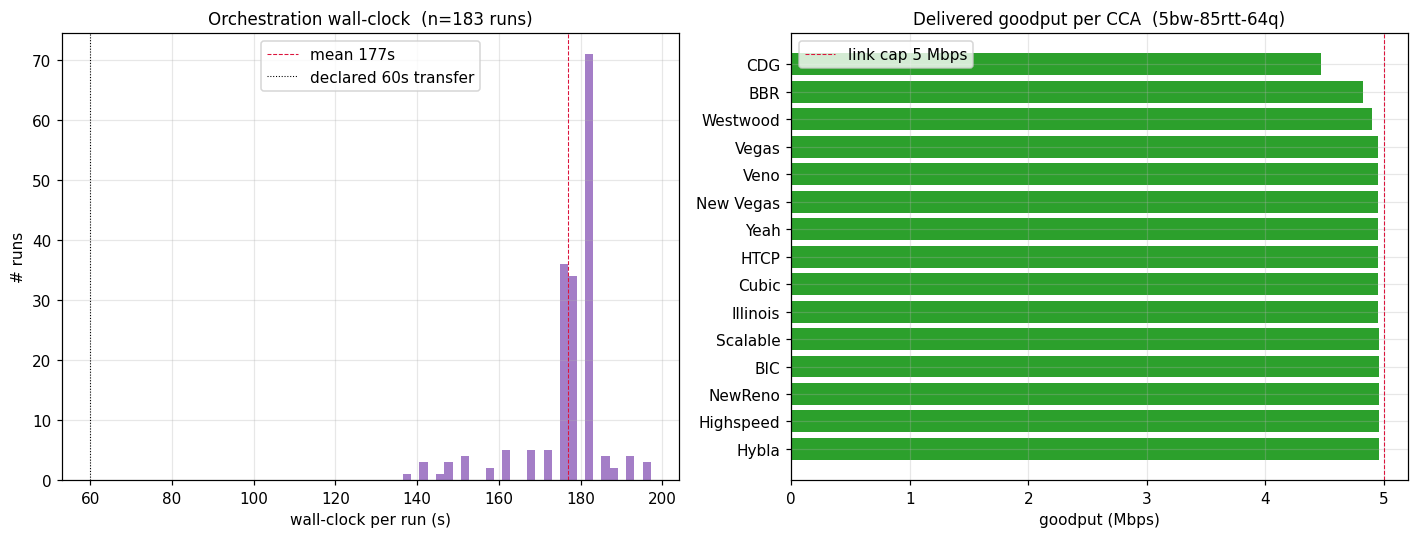

wall-clock: mean 176.9s  median 177.1s  min 136.5s  max 197.2s


,cc,paper,delivered_MB,goodput_Mbps
0,hybla,Hybla,37.17,4.96
1,highspeed,Highspeed,37.16,4.96
2,reno,NewReno,37.16,4.95
3,bic,BIC,37.16,4.95
4,scalable,Scalable,37.16,4.95
5,illinois,Illinois,37.16,4.95
6,cubic,Cubic,37.15,4.95
7,htcp,HTCP,37.15,4.95
8,yeah,Yeah,37.15,4.95
9,nv,New Vegas,37.13,4.95


In [7]:
timing = pd.read_csv(RESULTS / "timing.csv")
timing = timing[timing["status"] == "complete"].copy()
timing["setting"] = timing.apply(lambda r: f'{r.bw_mbps}bw-{r.rtt_ms}rtt-{r.queue_pkts}q', axis=1)

# Delivered volume + goodput for the 15 CCAs at the 5bw-85rtt-64q setting (fast: 15 files)
BW, RTT, Q, DUR = 5, 85, 64, 60
rows = []
for cc in ALL_CCS:
    tag = tag_for(cc, BW, RTT, Q)
    p = qtrace_path(tag)
    if p is None:
        continue
    _, _, bs = load_qtrace(tag)
    bs = bs[~pd.isna(bs)]
    mb = float(bs[-1]) / 1e6 if len(bs) else np.nan
    rows.append({"cc": cc, "paper": PAPER_NAME[cc], "delivered_MB": mb,
                 "goodput_Mbps": mb * 8 / DUR})
vol = pd.DataFrame(rows).sort_values("goodput_Mbps", ascending=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))

# (a) orchestration wall-clock per run
a1.hist(timing["wall_s"], bins=30, color="C4", alpha=0.85)
a1.axvline(timing["wall_s"].mean(), color="crimson", ls="--",
           label=f'mean {timing.wall_s.mean():.0f}s')
a1.axvline(60, color="k", ls=":", label="declared 60s transfer")
a1.set_xlabel("wall-clock per run (s)"); a1.set_ylabel("# runs")
a1.set_title(f"Orchestration wall-clock  (n={len(timing)} runs)"); a1.legend()

# (b) goodput per CCA at one setting
a2.barh(vol["paper"], vol["goodput_Mbps"], color="C2")
a2.axvline(BW, color="crimson", ls="--", label=f"link cap {BW} Mbps")
a2.set_xlabel("goodput (Mbps)"); a2.set_title(f"Delivered goodput per CCA  ({BW}bw-{RTT}rtt-{Q}q)")
a2.legend()
fig.tight_layout()
fig.savefig(FIGDIR / "fig_efficiency_summary.png")
plt.show()

print("wall-clock: mean %.1fs  median %.1fs  min %.1fs  max %.1fs"
      % (timing.wall_s.mean(), timing.wall_s.median(), timing.wall_s.min(), timing.wall_s.max()))
display(vol.reset_index(drop=True).round(2))


## Note — what this campaign can and cannot reproduce

**Reproduced above (queue-occupancy time series):** Fig. 1, Fig. 5, Fig. 6, Fig. 23 —
these are direct plots of the collected `veth2` backlog traces.

**Not reproducible from this pass:** the classifier figures **Fig. 7 (accuracy matrix),
Fig. 8/9 (nearest-neighbour + DTW distances), Fig. 10 (trace-length sensitivity),
Fig. 11/Table 2 (DTW distance CDF / thresholds), Fig. 12 (open-set)**. Those require the
1NN-DTW pipeline over a **separate training set (3 samples/CCA) and testing set
(5 samples/CCA)**. This campaign collected **one trial per (setting, CCA)** with no
train/test split and no repetitions, so there is nothing to hold out or vote over.

To get there: re-run the campaign with `num_trials >= 5` (and ideally a second seed pass
for a training library), then add a DTW step (e.g. `dtaidistance`/`tslearn`) that does
leave-one-out 1NN-DTW per setting and renders the per-setting accuracy heatmap (Fig. 7).
